In [8]:
# Equipe: Os Laplacianos
# Integrantes: Matheus Foresto Moselli, Marcos Vinicius Medeiros da Silva, Karl Eloy Marques Henrique
# Data: 30/03/2026  |  Programa: spv_contador_comprimidos.ipynb
# Descrição: SPV para contagem automática de comprimidos via processamento de imagem.
# Execução: jupyter notebook spv_contador_comprimidos.ipynb

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Definindo quantidade de comprimidos por imagem para etapas posteriores
ground_truth = {
    'n1.jpeg': 6,
    'n2.jpeg': 6,
    'n3.jpeg': 4,
    'n4.jpeg': 6,
}

In [9]:
# Pré-processamento
KERNEL_BLUR        = 31     # Tamanho do filtro Gaussiano
CLAHE_CLIP         = 2.0    # Limite de contraste do CLAHE
CLAHE_GRID         = (8, 8) # Grade de tiles do CLAHE

# Morfologia
KERNEL_MORPH       = 21     # Mantido igual ao código original

# Filtragem de regiões
AREA_MIN           = 1500   # Área mínima para considerar como comprimido (px²)
CIRCULARIDADE_MIN  = 0.6    # Circularidade mínima (0=qualquer, 1=círculo perfeito)

# Watershed
KERNEL_WATERSHED = 3
DIST_TRANSFORMATION_MASK_SIZE = 0
PERCENT_MAX_DISTANCE = 0.1

In [10]:
def preprocessar(img):
    """
    Aplica processamento de cores e equalização de histograma.

    Etapas:
        1. BGR → LAB  : separa luminância (L) de crominância (a, b),
                        tornando o contraste independente da cor.
        2. CLAHE      : equalização adaptativa com limite de contraste no
                        canal L — realça bordas de comprimidos sem
                        amplificar ruídos de fundo.
        3. Gaussiano  : suaviza ruídos de textura antes da binarização.

    Parâmetros:
        img : imagem BGR lida pelo OpenCV

    Retorna:
        blur     : imagem em tons de cinza suavizada (entrada para binarizar)
        img_rgb  : imagem original em RGB (para exibição via matplotlib)
    """
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Obtendo o canal L
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    canal_l = lab[:, :, 0]

    # Aplicando CLAHE (Contrast Limited Adaptive Histogram Equalization) no canal L
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    canal_l_eq = clahe.apply(canal_l)
    lab[:, :, 0] = canal_l_eq

    # Converter de volta para BGR e extrair cinza equalizado
    img_eq = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    gray   = cv2.cvtColor(img_eq, cv2.COLOR_BGR2GRAY)

    # Filtragem: Gaussiano
    blur = cv2.GaussianBlur(gray, (KERNEL_BLUR, KERNEL_BLUR), 0)

    return blur, img_rgb

In [11]:
def binarizar(blur):
    """
    Binariza a imagem e aplica operadores morfológicos.

    Etapas:
        1. Otsu      : limiar automático — separa comprimidos do fundo
                       sem parâmetro manual, adaptando-se a diferentes
                       iluminações.
        2. MORPH_OPEN: erosão seguida de dilatação com kernel 15×15 —
                       remove ruídos menores que o kernel e suaviza
                       bordas dos comprimidos.

    Parâmetros:
        blur : imagem em tons de cinza suavizada (saída de preprocessar)

    Retorna:
        opening : máscara binária com regiões de comprimidos
    """
    # Binarização Otsu
    _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Operadores Morfológicos
    kernel  = np.ones((KERNEL_MORPH, KERNEL_MORPH), np.uint8)

    # Remove mancas brancas pequenas
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # Remove buracos
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    return closing

In [12]:
def aplicar_watershed(img_binarizada, img_bgr):
    """
    Aplica o algoritmo Watershed para separar comprimidos sobrepostos.

    Etapas:
        1. Transformada de distância → picos = centros dos comprimidos
        2. Threshold nos picos → marcadores "frente certa" (objeto)
        3. Dilatação da máscara → marcadores "fundo certo"
        4. Região desconhecida = fundo_certo − frente_certa
        5. cv2.watershed() propaga os marcadores e traça bordas (−1)

    Parâmetros:
        img_binarizada  : máscara binária pós-morfologia (saída de binarizar)
        img_bgr  : imagem BGR original (necessária para cv2.watershed)

    Retorna:
        markers  : mapa de rótulos; cada comprimido recebe um ID único;
                   bordas Watershed marcadas com −1
    """
    kernel     = np.ones((KERNEL_WATERSHED, KERNEL_WATERSHED), np.uint8)
    fundo_certo = cv2.dilate(img_binarizada, kernel, iterations=3)

    dist_transform = cv2.distanceTransform(
        img_binarizada,
        cv2.DIST_L2,
        DIST_TRANSFORMATION_MASK_SIZE
    )

    _, frente_certa = cv2.threshold(
        dist_transform,
        PERCENT_MAX_DISTANCE * dist_transform.max(),
        255,
        0
    )

    frente_certa = np.uint8(frente_certa)

    desconhecido = cv2.subtract(fundo_certo, frente_certa)

    _, markers = cv2.connectedComponents(frente_certa)
    markers = markers + 1
    markers[desconhecido == 255] = 0

    markers = cv2.watershed(img_bgr, markers)
    # markers == -1 → borda entre dois objetos
    # markers == 1  → fundo
    # markers >= 2  → cada comprimido

    return markers

In [13]:
def exibir_deteccao_comprimidos(caminho_imagem,
                                area_min=AREA_MIN,
                                circularidade_min=CIRCULARIDADE_MIN,
                                dose_esperada=0):
    """
    Extrai os comprimidos de uma imagem e exibe os resultados.

    Parâmetros:
        caminho_imagem    : caminho para o arquivo de imagem
        area_min          : área mínima (px²) para considerar como comprimido
        circularidade_min : circularidade mínima [0, 1]
        dose_esperada     : se > 0, compara com o detectado e exibe status
        mostrar_pipeline  : se True, exibe todas as etapas intermediárias
    """
    global AREA_MIN, CIRCULARIDADE_MIN
    AREA_MIN, CIRCULARIDADE_MIN = area_min, circularidade_min

    img = cv2.imread(caminho_imagem)
    if img is None:
        print(f"Erro ao carregar: {caminho_imagem}")
        return

    nome = os.path.basename(caminho_imagem)

    # Aplicando etapas de tratamento
    blur, img_rgb = preprocessar(img)
    closing = binarizar(blur)
    markers = aplicar_watershed(closing, img.copy())

    # Exibição das etapas
    # Mapa de rótulos colorido para visualizar o Watershed
    watershed_vis = np.zeros((*markers.shape, KERNEL_WATERSHED), dtype=np.uint8)
    for rid in np.unique(markers):
        if rid <= 1:
            continue

        cor = tuple(
            int(c) for c in np.random.randint(80, 255, 3, dtype=np.uint8)
        )

        watershed_vis[markers == rid] = cor

    # Bordas Watershed em vermelho
    watershed_vis[markers == -1] = (255, 0, 0)

    fig, axes = plt.subplots(1, 5, figsize=(26, 6))

    axes[0].imshow(img_rgb)
    axes[0].set_title(f"1. Original\n{nome}", fontsize=10)

    axes[1].imshow(blur, cmap='gray')
    axes[1].set_title("2. Pré-proc.\nCLAHE + Gaussiano", fontsize=10)

    axes[2].imshow(closing, cmap='gray')
    axes[2].set_title("3. Máscara\nOtsu + OPEN", fontsize=10)

    axes[3].imshow(watershed_vis)
    axes[3].set_title("4. Watershed\n(cada cor = 1 objeto)", fontsize=10)


    for ax in axes:
        ax.axis('off')

    plt.suptitle(
        "Os Laplacianos — Pipeline SPV",
        fontweight='bold',
        fontsize=13,
        y=1.01
    )

    plt.tight_layout()
    plt.show()

4 imagem(ns) encontrada(s) em 'images'



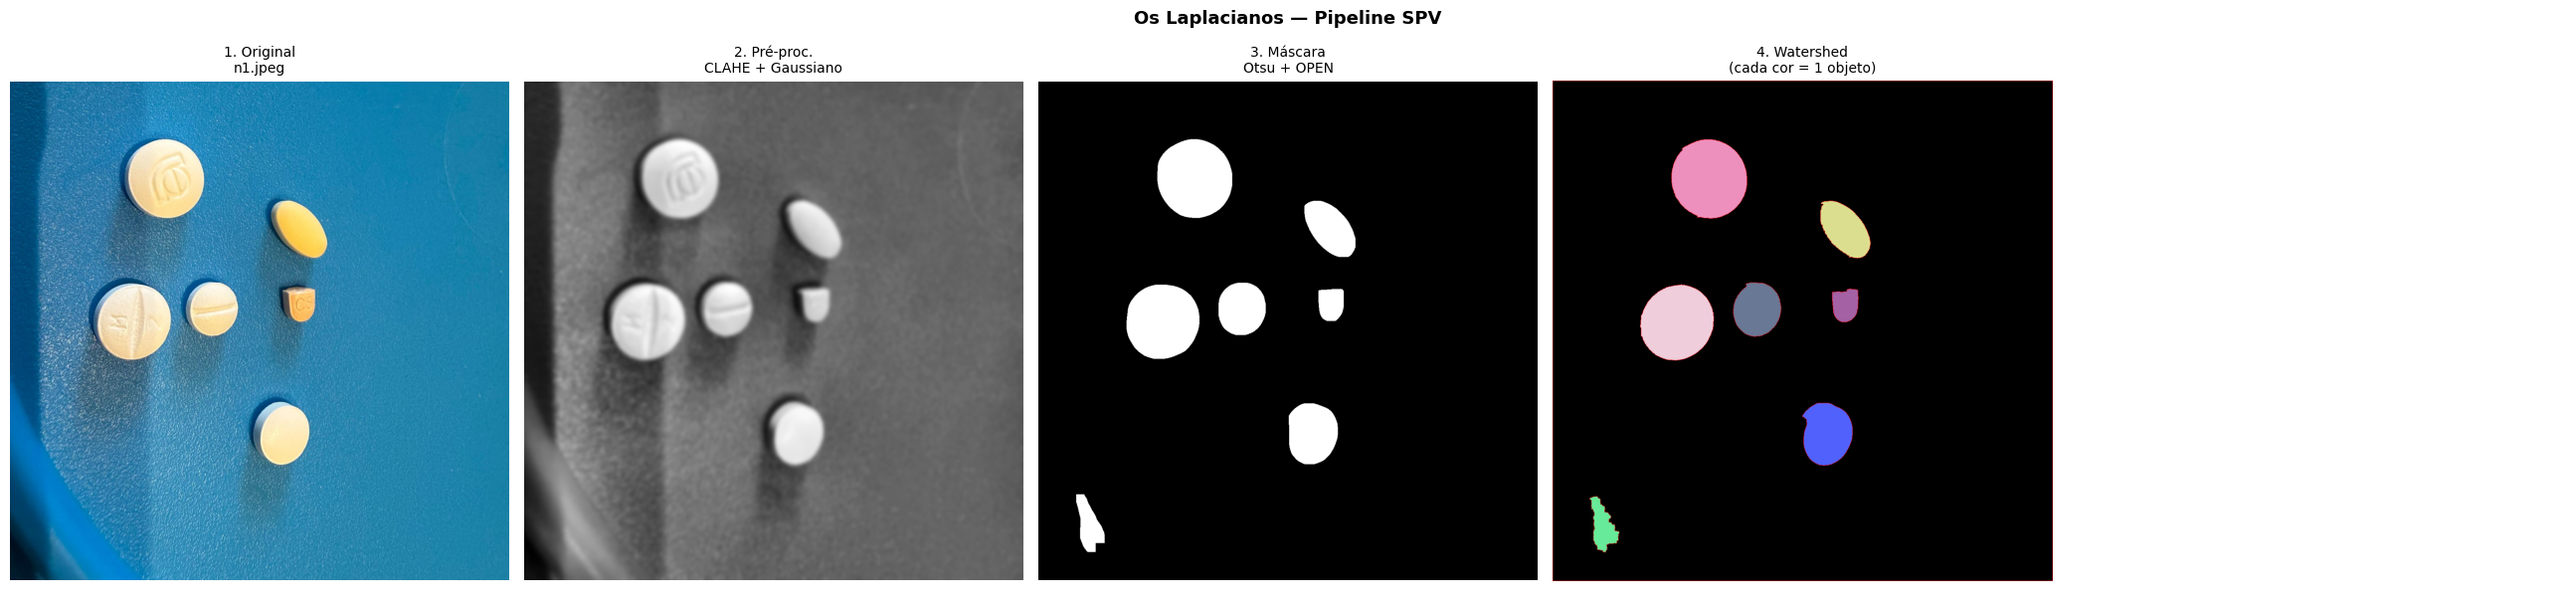

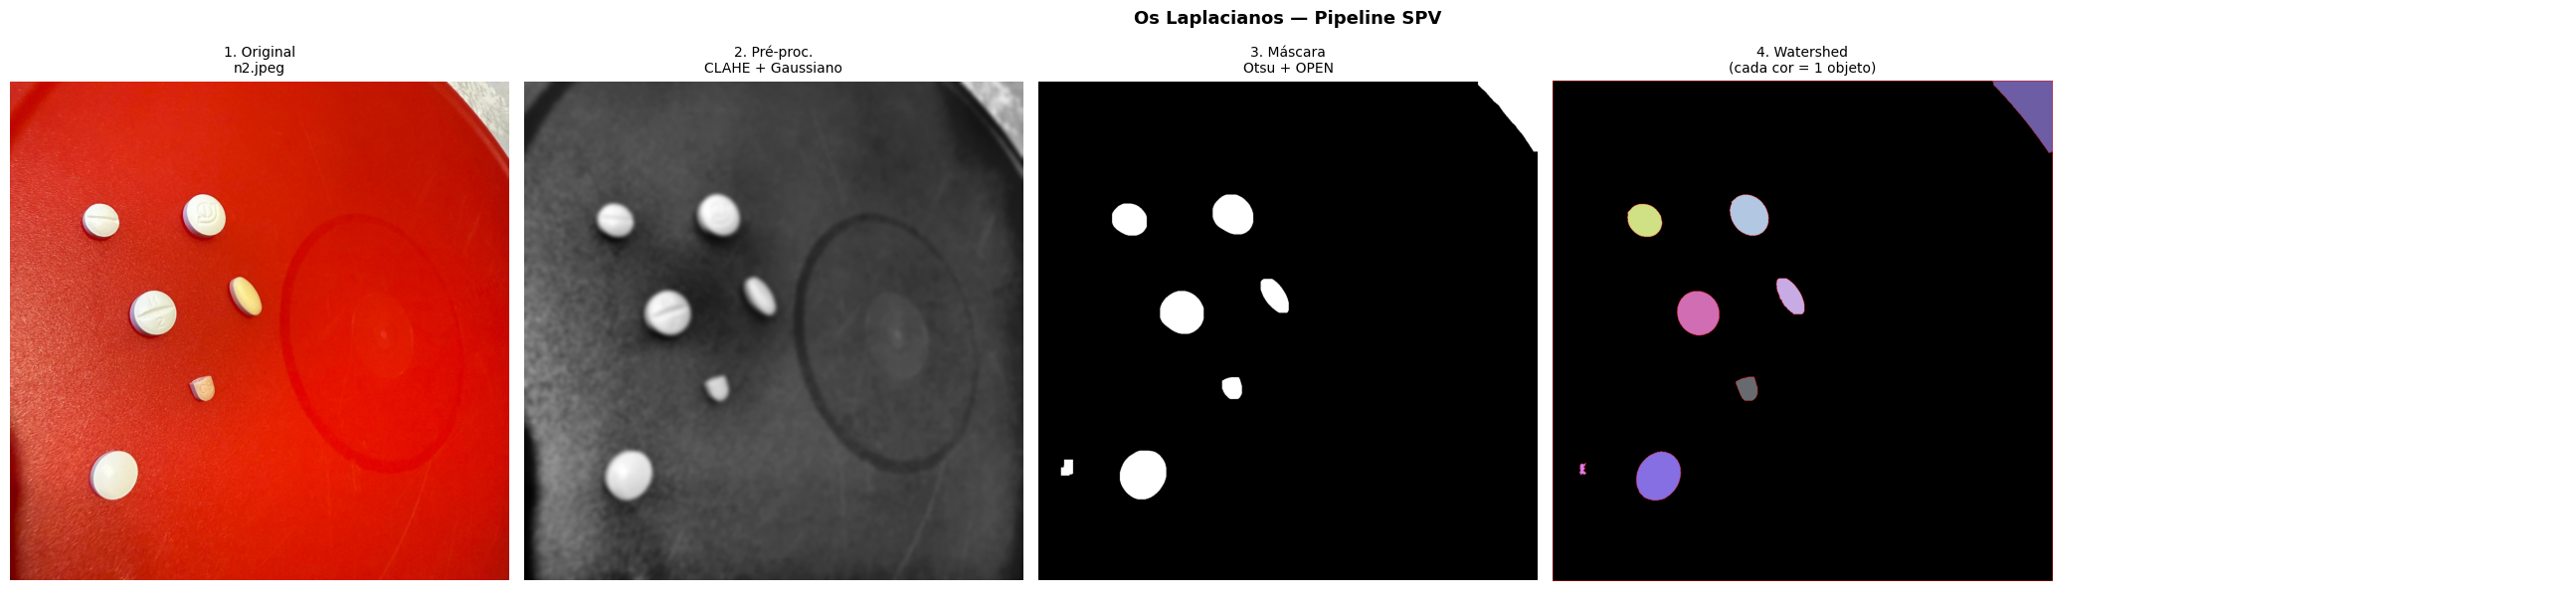

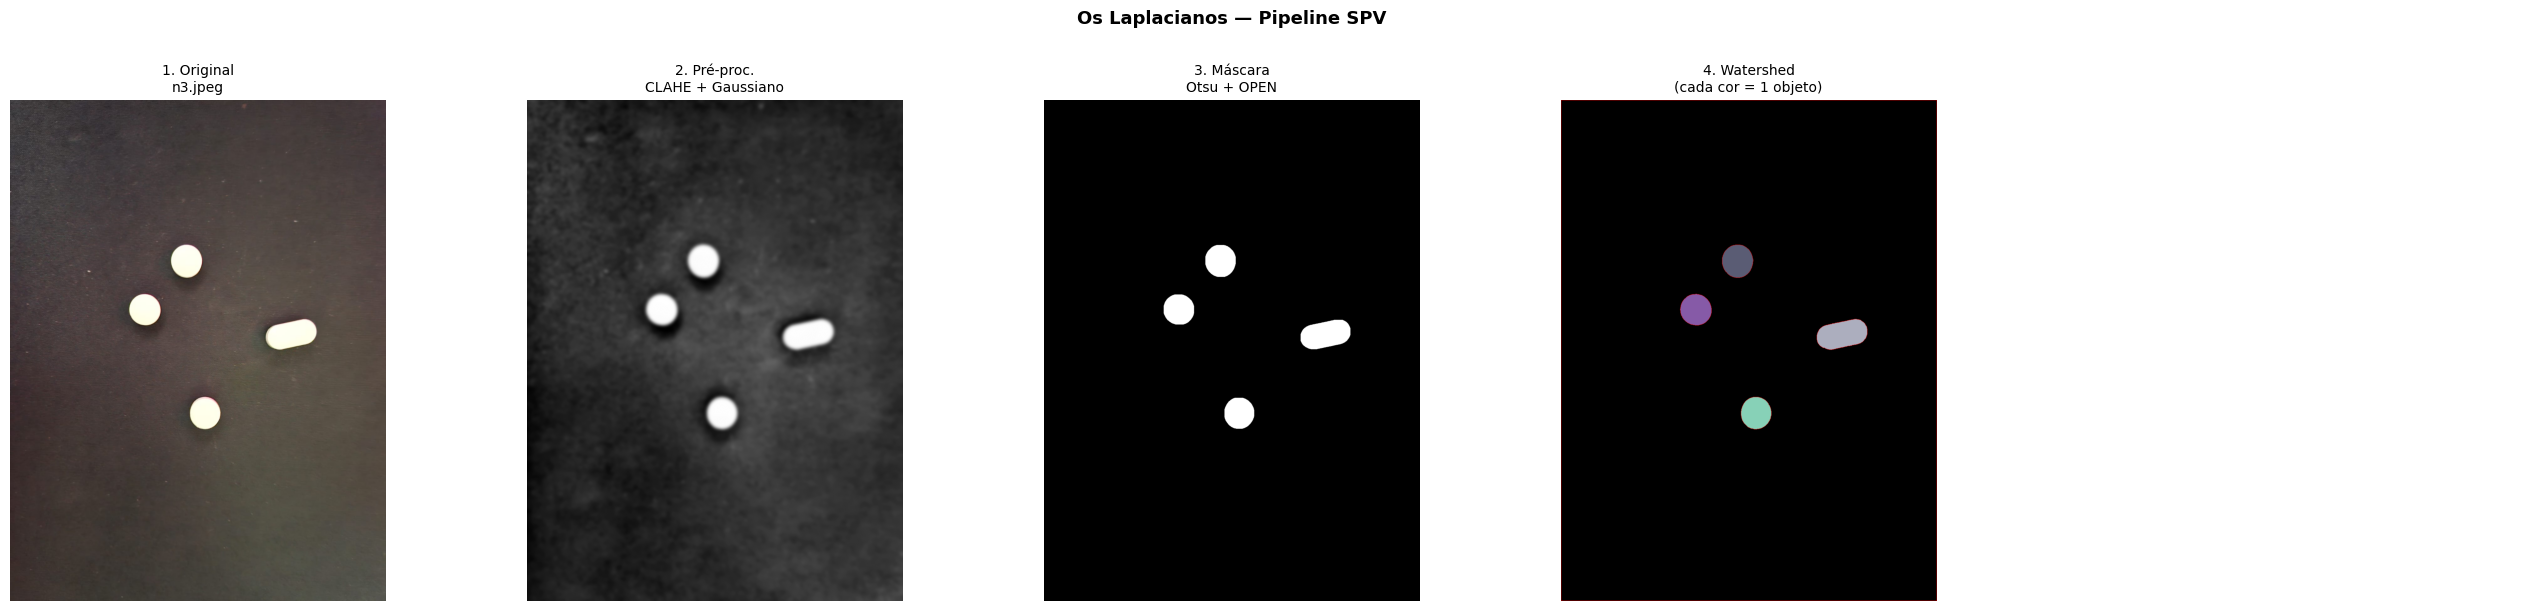

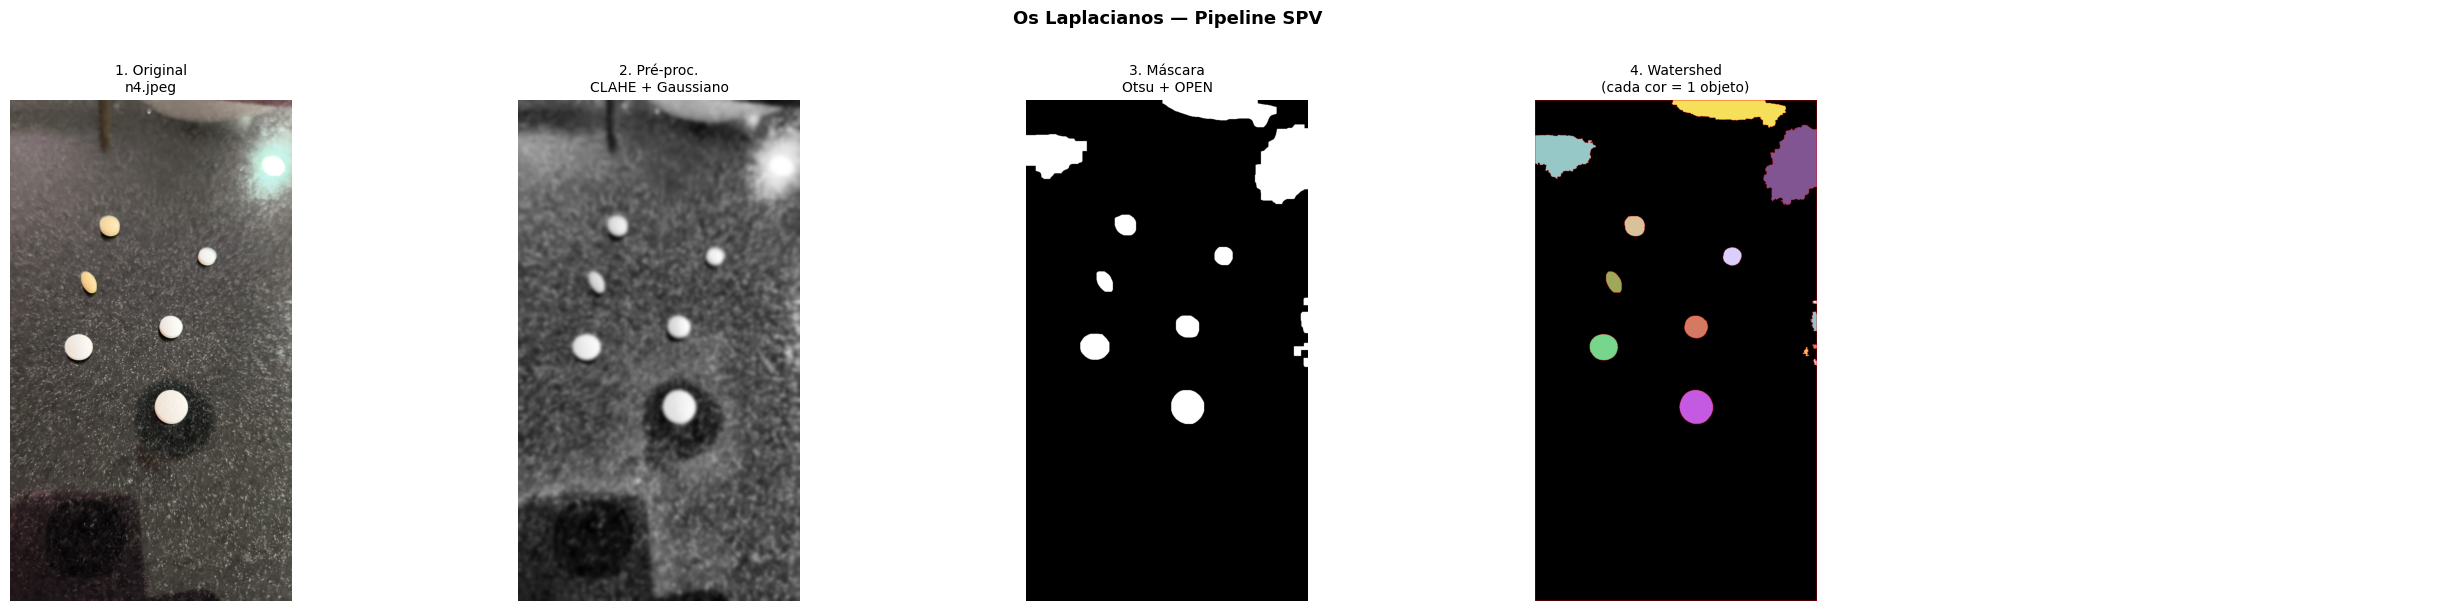

In [14]:
pasta = "images"
extensoes = ('.jpg', '.jpeg', '.png')

if os.path.exists(pasta):
    arquivos = sorted([f for f in os.listdir(pasta)
                       if f.lower().endswith(extensoes)])
    print(f"{len(arquivos)} imagem(ns) encontrada(s) em '{pasta}'\n")

    resultados = {}  # guarda contagens para análise posterior

    for arquivo in arquivos:
        caminho = os.path.join(pasta, arquivo)

        # Detecta n comprimidos na imagem
        exibir_deteccao_comprimidos(
          caminho,
          dose_esperada=ground_truth[arquivo]
        )
else:
    print(f"Pasta '{pasta}' não encontrada.")